In [48]:
input_num = 5

In [50]:
exorcism_data = {}
with open(f'data/exorcism_rand_tcost_{input_num}.txt', 'r') as f:
        exorcism_data = {int(k): int(v)
                 for line in f
                 for k, v in (line.strip().split(':'),)}

our_data = {}
with open(f'data/our_rand_tcost_{input_num}.txt', 'r') as f:
        our_data = {int(k): int(v)
                 for line in f
                 for k, v in (line.strip().split(':'),)}

In [51]:
dif = {}
better, eqv, worse = 0, 0, 0
for k in exorcism_data:
    dif[k] = exorcism_data[k]-our_data[k]
    if dif[k]>0:
        better+=1
    elif dif[k]==0:
        eqv+=1
    else:
        worse+=1
dif_col = {}
for k in dif:
    if not dif[k] in dif_col:
        dif_col[dif[k]] = 1
    else:
        dif_col[dif[k]] += 1
sorted_dif_col = dict(sorted(dif_col.items()))
print(sorted_dif_col)

print("****** Comparison of TDD-based Method Alg. 2 to Exorcism  ******")
# print(len(exorcism_data))
print(f"number of input variables: {input_num}")
print(f"lower  t-cost in {better}({better / len(exorcism_data) * 100}%) cases")
print(f"higher t-cost in {worse}({worse / len(exorcism_data) * 100}%) cases")
print(f"same   t-cost in {eqv}({eqv / len(exorcism_data) * 100}%) cases")
print("****** ******  ******")

{-88: 1, -87: 1, -82: 1, -81: 2, -80: 4, -79: 9, -78: 4, -77: 1, -75: 3, -73: 20, -72: 11, -71: 10, -70: 2, -69: 1, -68: 1, -67: 1, -66: 16, -65: 18, -64: 21, -63: 28, -62: 13, -61: 4, -58: 30, -57: 47, -56: 63, -55: 34, -54: 9, -53: 2, -52: 1, -51: 30, -50: 43, -49: 160, -48: 105, -47: 73, -46: 15, -45: 8, -44: 20, -43: 36, -42: 234, -41: 248, -40: 281, -39: 71, -38: 33, -37: 12, -36: 57, -35: 168, -34: 270, -33: 479, -32: 371, -31: 163, -30: 40, -29: 60, -28: 106, -27: 280, -26: 356, -25: 544, -24: 375, -23: 159, -22: 78, -21: 132, -20: 312, -19: 419, -18: 555, -17: 385, -16: 379, -15: 174, -14: 177, -13: 365, -12: 636, -11: 838, -10: 607, -9: 400, -8: 224, -7: 158, -6: 283, -5: 601, -4: 1076, -3: 1240, -2: 878, -1: 370, 0: 187, 1: 251, 2: 432, 3: 982, 4: 1428, 5: 1627, 6: 1065, 7: 388, 8: 151, 9: 292, 10: 589, 11: 1282, 12: 1672, 13: 1654, 14: 1112, 15: 344, 16: 214, 17: 400, 18: 1021, 19: 1475, 20: 1751, 21: 1461, 22: 840, 23: 330, 24: 289, 25: 667, 26: 1262, 27: 1854, 28: 1608, 29

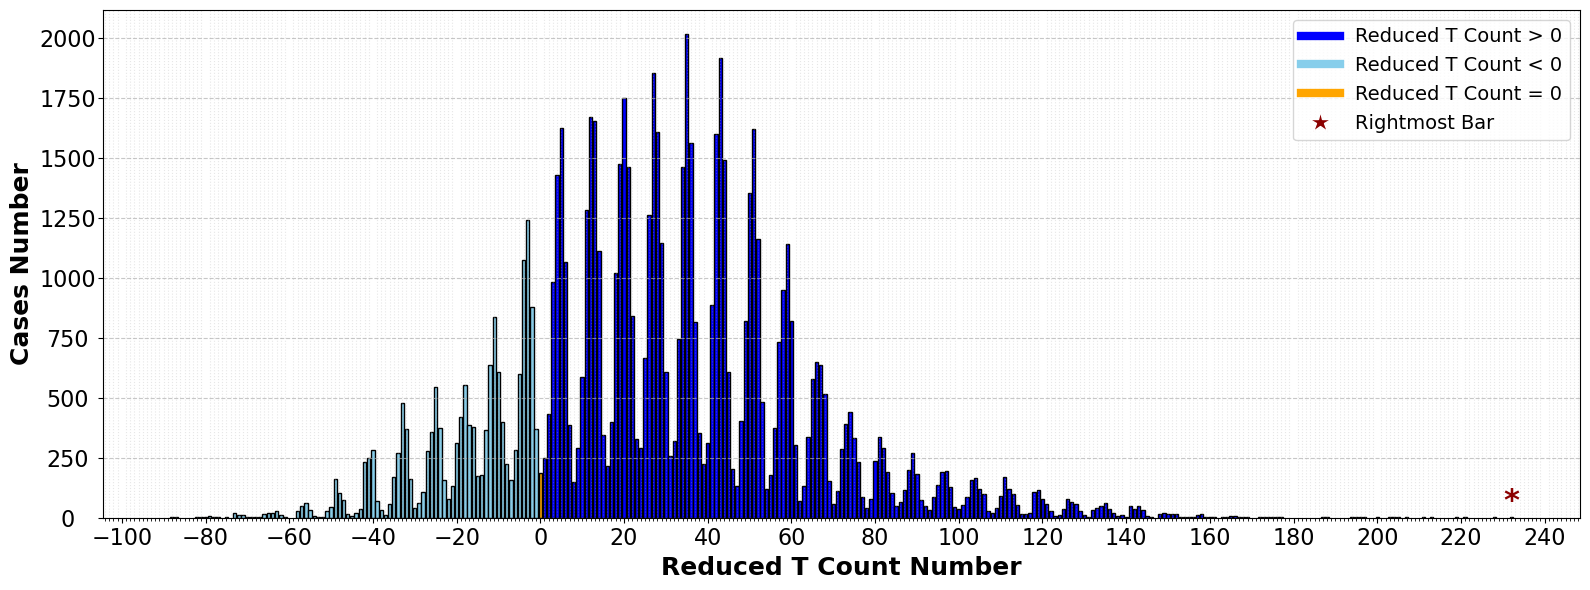

In [53]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# 原始数据
data = sorted_dif_col
# 提取键和值，并按键排序
sorted_keys = sorted(data.keys())
sorted_values = [data[key] for key in sorted_keys]

# 根据键的正负分配颜色：大于0为绿色，小于0为天蓝，0为橙色（突出显示）
colors = []
for key in sorted_keys:
    if key > 0:
        colors.append('blue')
    elif key < 0:
        colors.append('skyblue')
    else:
        colors.append('orange')  # 键为0时用橙色

# 设置画布
plt.figure(figsize=(16, 6))

# 绘制柱状图（指定颜色列表）
bars = plt.bar(sorted_keys, sorted_values, color=colors, edgecolor='black', width=0.8)




# 直接获取最右边柱子的索引（排序后列表的最后一个元素）
rightmost_idx = -1  # 列表最后一个元素的索引
rightmost_key = sorted_keys[rightmost_idx]
rightmost_value = sorted_values[rightmost_idx]

rightmost_bar = bars[rightmost_idx]
# 在柱子顶部添加红色星号，位置稍作调整确保不被裁剪
plt.text(
    rightmost_key,  # x坐标与柱子对齐
    rightmost_value + 8,  # y坐标向上偏移8，适配小值柱子
    '*',
    ha='center',
    va='bottom',
    fontsize=22,  # 星号放大，更醒目
    color='darkred',
    fontweight='bold'
)



# 添加标题和标签
# plt.title(f'Experiment Result of {input_num} Variable Boolean Functions', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Reduced T Count Number', fontsize=18, fontweight='bold')
plt.ylabel('Cases Number', fontsize=18, fontweight='bold')

# 设置x轴刻度间隔为2，添加次刻度
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(axis='x', which='minor', linestyle=':', alpha=0.3)

# 优化标签显示
plt.xticks(rotation=0, ha='center', fontsize=16)
plt.yticks(rotation=0, ha='center', fontsize=16)
ax.tick_params(axis='y', pad=22)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 添加图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=6, label='Reduced T Count > 0'),
    Line2D([0], [0], color='skyblue', lw=6, label='Reduced T Count < 0'),
    Line2D([0], [0], color='orange', lw=6, label='Reduced T Count = 0'),
    Line2D([0], [0], marker='*', markersize=16, color='w', markerfacecolor='darkred', label='Rightmost Bar')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=14)
plt.tight_layout()

plt.savefig(f'Experiment_{input_num}_var.pdf', dpi=30000, bbox_inches='tight', format='pdf')
plt.show()

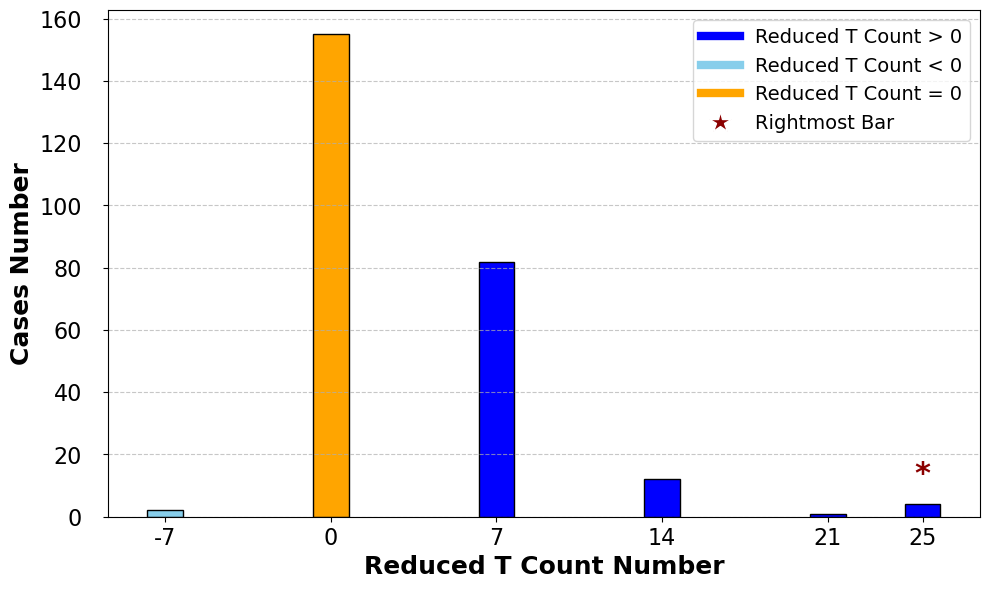

In [22]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

# 原始数据（仅包含有数据的键）
data = {-7: 2, 0: 155, 7: 82, 14: 12, 21: 1, 25: 4}

# 提取键和值，并按键排序（仅包含有数据的键）
sorted_keys = sorted(data.keys())
sorted_values = [data[key] for key in sorted_keys]

# 根据键的正负分配颜色
colors = []
for key in sorted_keys:
    if key > 0:
        colors.append('blue')
    elif key < 0:
        colors.append('skyblue')
    else:
        colors.append('orange')

# 设置画布
plt.figure(figsize=(10, 6))  # 缩小宽度，避免柱子过散

# 绘制柱状图（仅包含有数据的柱子）
bars = plt.bar(sorted_keys, sorted_values, color=colors, edgecolor='black', width=1.5)  # 适当加宽柱子

# 最右边柱子标注星号
rightmost_idx = -1
rightmost_key = sorted_keys[rightmost_idx]
rightmost_value = sorted_values[rightmost_idx]
plt.text(
    rightmost_key,
    rightmost_value + 5,  # 调整偏移量适配当前数据范围
    '*',
    ha='center',
    va='bottom',
    fontsize=22,
    color='darkred',
    fontweight='bold'
)

# 添加标题和标签
plt.xlabel('Reduced T Count Number', fontsize=18, fontweight='bold')
plt.ylabel('Cases Number', fontsize=18, fontweight='bold')

# 关键：x轴只显示有数据的键（固定刻度为sorted_keys）
ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator(sorted_keys))  # 仅显示有数据的键作为刻度
plt.xticks(sorted_keys, sorted_keys, rotation=0, ha='center', fontsize=16)  # 刻度标签为数据中的键

# 优化y轴标签间距
plt.yticks(fontsize=16)
ax.tick_params(axis='y', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 添加图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=6, label='Reduced T Count > 0'),
    Line2D([0], [0], color='skyblue', lw=6, label='Reduced T Count < 0'),
    Line2D([0], [0], color='orange', lw=6, label='Reduced T Count = 0'),
    Line2D([0], [0], marker='*', markersize=16, color='w', markerfacecolor='darkred', label='Rightmost Bar')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=14)

plt.tight_layout()
# 注意：dpi无需设置30000（过大导致文件异常，300足够高清）
# plt.savefig(f'Experiment_{input_num}_var_2.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

In [39]:
t_r = 0
n = 0
for k in sorted_dif_col:
    if k>100:
        t_r+=k*sorted_dif_col[k]
        n+=sorted_dif_col[k]
print(t_r,n,t_r/n)

320773 2662 120.50075131480091


In [47]:


our_data_6 = {}
for k in range(7):
    temp = {}
    with open(f'our_rand_tcost_6_s{k+1}.txt', 'r') as f:
        temp = {int(k): int(v)
                 for line in f
                 for k, v in (line.strip().split(':'),)}
    our_data_6= our_data_6|temp
len(our_data_6)

with open(f'our_rand_tcost_6.txt', 'w') as f:
        for k, v in our_data_6.items():
            f.write(f'{k}:{v}\n')